# Lab: Decision Trees for Classification and Regression

## A guided practical session with questions

**Alex Sánchez**  
**Python version**

This notebook is the Python equivalent of the reduced R lab on decision trees for classification and regression. It follows the same structure and keeps the same pedagogical aim: not only to fit trees, but to interpret them, assess prediction error, and understand pruning.

## Learning goals

This lab is intended to provide an active exercise on classification and regression trees to illustrate how they can be built, used, interpreted and applied.

The main goal is not only to fit a decision tree, but to understand:

1. how a tree partitions the predictor space;
2. how a fitted tree produces class predictions and class probabilities;
3. why training error is not enough to assess prediction performance;
4. how pruning controls model complexity;
5. how the same ideas change when the response is quantitative rather than categorical.

The lab is intentionally written so that most questions are transferable to any similar dataset. The default dataset used here is the Pima Indians diabetes dataset, but the structure can be reused with another classification dataset with minimal changes.

**Note on the questions.** Questions are numbered automatically using Markdown ordered lists. Some optional questions are kept in the source file as HTML comments. To recover one of them, simply remove the comment delimiters `<!--` and `-->`; the list will be renumbered automatically when the notebook is rendered.


# Packages

We use `pandas` for data manipulation, `scikit-learn` for decision trees and model assessment, and `matplotlib` for plotting.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, mean_squared_error

pd.set_option("display.max_columns", None)


# Part 1. Classification tree

## 1.1 Data and prediction problem

In this example we use the `PimaIndiansDiabetes2` dataset from the R package `mlbench`.

The cell below first tries to read a local file called `PimaIndiansDiabetes2.csv`. If it is not found, it downloads the dataset from the `Rdatasets` repository. If you use a different dataset, replace this cell with the corresponding data import code.


In [19]:
from pathlib import Path
path = Path("C:/Users/maria.liliu.martine/Documents/Task_2.1/Exercise")
print(path.exists())
local_file = path / "PimaIndiansDiabetes2.csv"
try:
    mydataset = pd.read_csv(local_file, index_col=0)
except FileNotFoundError:
    print(f"File not found at {local_file}. Attempting to load from URL.")

"""  
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/mlbench/PimaIndiansDiabetes2.csv"

if local_file.exists():
    mydataset = pd.read_csv(local_file)
else:
    mydataset = pd.read_csv(url)

# The Rdatasets version contains a first index column called 'rownames'.
if "rownames" in mydataset.columns:
    mydataset = mydataset.drop(columns="rownames")
"""
mydataset.head()


True


,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
1,6,148.0,72.0,35.0,NaN,33.6,0.627,50,pos
2,1,85.0,66.0,29.0,NaN,26.6,0.351,31,neg
3,8,183.0,64.0,NaN,NaN,23.3,0.672,32,pos
4,1,89.0,66.0,23.0,94.0,28.1,0.167,21,neg
5,0,137.0,40.0,35.0,168.0,43.1,2.288,33,pos


The response variable is `diabetes`, a binary variable indicating whether each individual is classified as diabetes-positive or diabetes-negative.


In [20]:
mydataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 1 to 768
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   763 non-null    float64
 2   pressure  733 non-null    float64
 3   triceps   541 non-null    float64
 4   insulin   394 non-null    float64
 5   mass      757 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   diabetes  768 non-null    object 
dtypes: float64(6), int64(2), object(1)
memory usage: 60.0+ KB


In [21]:
mydataset.describe(include="all")


,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neg
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,NaN
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,NaN
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,NaN
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,NaN
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,NaN
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,NaN


In [22]:
mydataset.isna().sum()


pregnant      0
glucose       5
pressure     35
triceps     227
insulin     374
mass         11
pedigree      0
age           0
diabetes      0
dtype: int64

## Questions

1. What is the response variable? Is this a classification or a regression problem?

1. Identify at least three predictors. For each one, indicate whether it is quantitative or categorical.

1. Before fitting a tree, inspect the data. Are there missing values? If so, in which variables? Why could missing values matter for model fitting and model assessment?

> Write your answers here or, if available, in the online form provided for the exercise.


## 1.2 Minimal preprocessing

Given this is a classroom lab, we will remove all missing values and use only *complete cases*. This is not necessarily the best strategy in a real analysis, but it keeps the focus on tree construction and model assessment.


In [23]:
mydataset_cc = mydataset.dropna().copy()

print("Original dimensions:", mydataset.shape)
print("Complete-case dimensions:", mydataset_cc.shape)

print("Class distribution in the original dataset:")
print(mydataset["diabetes"].value_counts())

print("Class distribution after complete-case filtering:")
print(mydataset_cc["diabetes"].value_counts())


Original dimensions: (768, 9)
Complete-case dimensions: (392, 9)
Class distribution in the original dataset:
diabetes
neg    500
pos    268
Name: count, dtype: int64
Class distribution after complete-case filtering:
diabetes
neg    262
pos    130
Name: count, dtype: int64


## Questions

1. What is the consequence of using `dropna()`? In a real study, what alternative preprocessing strategy could be considered?

> Write your answers here or, if available, in the online form provided for the exercise.


## 1.3 Train/test split

We split the dataset into training and test sets. The model will be fitted using the training set and evaluated using the test set.

In this Python version we use a stratified split, so that the class proportions are preserved as much as possible in the training and test sets.


In [24]:
random_state = 123
prop_train = 0.70

X = mydataset_cc.drop(columns="diabetes")
y = mydataset_cc["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=prop_train,
    random_state=random_state,
    stratify=y
)

train_data = X_train.copy()
train_data["diabetes"] = y_train

test_data = X_test.copy()
test_data["diabetes"] = y_test

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

print("Training class distribution:")
print(y_train.value_counts())

print("Test class distribution:")
print(y_test.value_counts())


Training set size: 274
Test set size: 118
Training class distribution:
diabetes
neg    183
pos     91
Name: count, dtype: int64
Test class distribution:
diabetes
neg    79
pos    39
Name: count, dtype: int64


## Questions

1. Why do we split the data into training and test sets instead of evaluating the tree on the same data used to fit it?

1. Check whether the class distribution is similar in the training and test sets. Why could a very unbalanced split be problematic?

> Write your answers here or, if available, in the online form provided for the exercise.


# Part 2. Fitting and interpreting a classification tree

## 2.1 Fit an initial tree

We fit a classification tree using `DecisionTreeClassifier()` from `scikit-learn`.

The initial tree is intentionally allowed to grow relatively freely. Later we will prune it using cost-complexity pruning.


In [34]:
from typing_extensions import Literal


tree_class = DecisionTreeClassifier(
    criterion="gini",
    random_state=random_state,
    ccp_alpha=0.01,
    splitter = "best",
    max_depth = 5,
    min_samples_split = 2,
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0,
    max_features = None,
    max_leaf_nodes = None,
    min_impurity_decrease = 0,
    class_weight = None,
)

tree_class.fit(X_train, y_train)

print(export_text(tree_class, feature_names=list(X_train.columns), max_depth=4))


|--- glucose <= 127.50
|   |--- insulin <= 149.00
|   |   |--- class: neg
|   |--- insulin >  149.00
|   |   |--- age <= 28.50
|   |   |   |--- class: neg
|   |   |--- age >  28.50
|   |   |   |--- class: pos
|--- glucose >  127.50
|   |--- glucose <= 154.50
|   |   |--- age <= 23.50
|   |   |   |--- class: neg
|   |   |--- age >  23.50
|   |   |   |--- pregnant <= 3.50
|   |   |   |   |--- insulin <= 199.00
|   |   |   |   |   |--- class: pos
|   |   |   |   |--- insulin >  199.00
|   |   |   |   |   |--- class: neg
|   |   |   |--- pregnant >  3.50
|   |   |   |   |--- class: neg
|   |--- glucose >  154.50
|   |   |--- insulin <= 87.50
|   |   |   |--- class: neg
|   |   |--- insulin >  87.50
|   |   |   |--- class: pos



In [26]:
X_train

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age
162,7,102.0,74.0,40.0,105.0,37.2,0.204,45
547,5,187.0,76.0,27.0,207.0,43.6,1.034,53
683,0,95.0,64.0,39.0,105.0,44.6,0.366,22
29,13,145.0,82.0,19.0,110.0,22.2,0.245,57
160,17,163.0,72.0,41.0,114.0,40.9,0.817,47
...,...,...,...,...,...,...,...,...
397,3,96.0,56.0,34.0,115.0,24.7,0.944,39
357,1,125.0,50.0,40.0,167.0,33.3,0.962,28
716,7,187.0,50.0,33.0,392.0,33.9,0.826,34
542,3,128.0,72.0,25.0,190.0,32.4,0.549,27


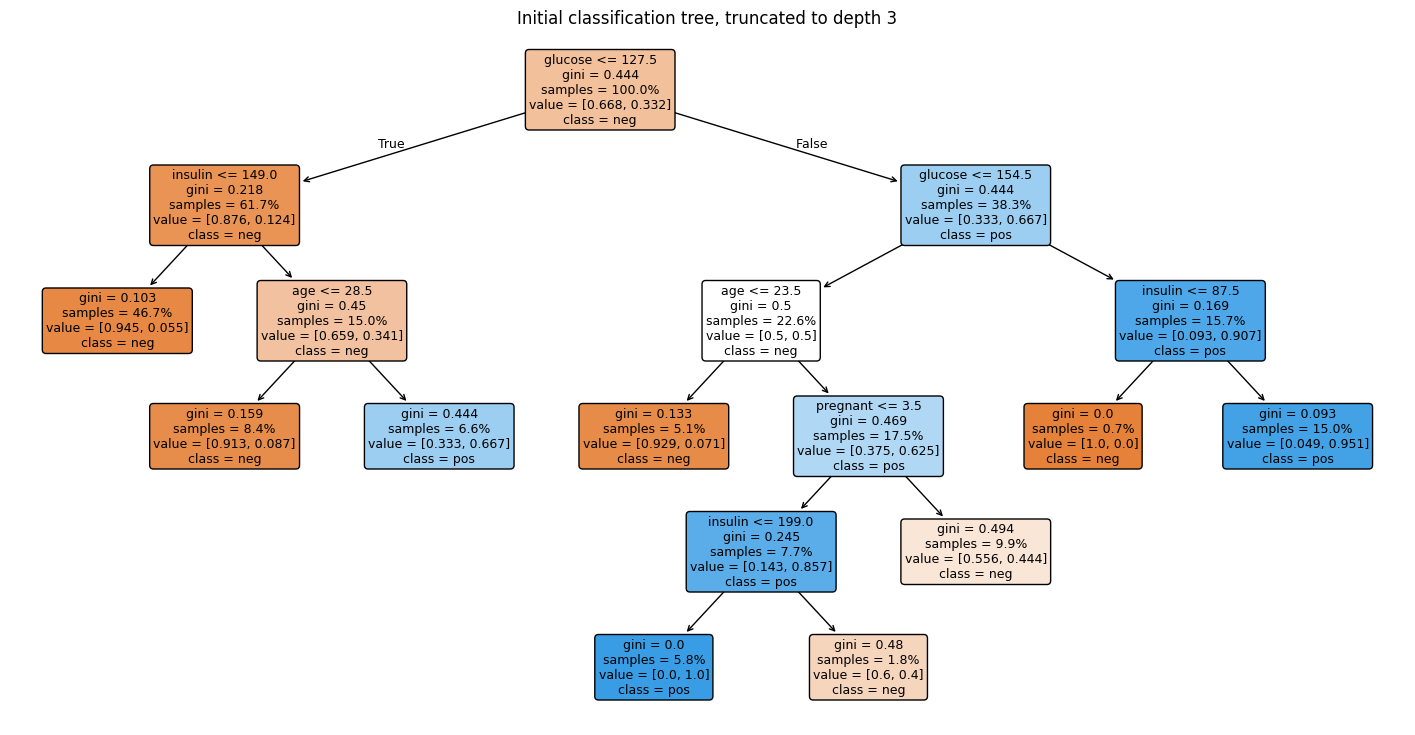

In [36]:
plt.figure(figsize=(18, 9))
plot_tree(
    tree_class,
    feature_names=X_train.columns,
    class_names=tree_class.classes_,
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=5,
    fontsize=9
)
plt.title("Initial classification tree, truncated to depth 3")
plt.show()


The plot displays the splitting variable and threshold, the impurity measure, the class proportions and the predicted class in each node. For readability, the displayed tree is truncated to depth 3. The fitted tree itself may be larger.

## Questions

1. Which predictor appears in the root node? What does this suggest about its predictive role in this fitted tree?

1. Choose one internal split. Explain it as a decision rule of the form: "if predictor X is below/above a threshold, then observations go to...".

<!--
1. Choose one terminal node. What is the predicted class in that node? What are the estimated class probabilities?
-->

1. Explain, in your own words, how the tree transforms a vector of predictors $x$ into a class prediction $\hat{y}$.

> Write your answers here or, if available, in the online form provided for the exercise.


# Part 3. Training error, test error and confusion matrix

## 3.1 Predictions on train and test data


In [37]:
pred_train_class = tree_class.predict(X_train)
pred_test_class = tree_class.predict(X_test)

labels = ["neg", "pos"]

conf_train = pd.DataFrame(
    confusion_matrix(y_train, pred_train_class, labels=labels),
    index=[f"Observed {x}" for x in labels],
    columns=[f"Predicted {x}" for x in labels]
)

conf_test = pd.DataFrame(
    confusion_matrix(y_test, pred_test_class, labels=labels),
    index=[f"Observed {x}" for x in labels],
    columns=[f"Predicted {x}" for x in labels]
)

print("Training confusion matrix")
display(conf_train)

print("Test confusion matrix")
display(conf_test)

train_error = 1 - accuracy_score(y_train, pred_train_class)
test_error = 1 - accuracy_score(y_test, pred_test_class)

print("Training error:", train_error)
print("Test error:", test_error)


Training confusion matrix


,Predicted neg,Predicted pos
Observed neg,175,8
Observed pos,24,67


Test confusion matrix


,Predicted neg,Predicted pos
Observed neg,63,16
Observed pos,20,19


Training error: 0.11678832116788318
Test error: 0.30508474576271183


## 3.2 Accuracy, sensitivity and specificity

For a binary classification problem, accuracy is often not enough. We also compute sensitivity and specificity. In this dataset, the positive class is coded as `pos`.


In [38]:
def classification_metrics(observed, predicted, positive="pos"):
    labels = list(pd.Series(observed).astype(str).unique())
    if positive not in labels:
        raise ValueError("The specified positive class is not present in the observed data.")
    negative = [x for x in sorted(labels) if x != positive][0]
    
    cm = confusion_matrix(observed, predicted, labels=[negative, positive])
    TN, FP, FN, TP = cm.ravel()
    
    accuracy = (TP + TN) / cm.sum()
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    test_error = 1 - accuracy
    
    return pd.DataFrame({
        "accuracy": [accuracy],
        "sensitivity": [sensitivity],
        "specificity": [specificity],
        "test_error": [test_error]
    })

classification_metrics(y_train, pred_train_class, positive="pos")


,accuracy,sensitivity,specificity,test_error
0,0.883212,0.736264,0.956284,0.116788


In [39]:
classification_metrics(y_test, pred_test_class, positive="pos")


,accuracy,sensitivity,specificity,test_error
0,0.694915,0.487179,0.797468,0.305085


## Questions

1. Compare the training error and the test error. Which one is smaller? Is this expected?

1. Why is the training error usually an optimistic estimate of prediction error?

<!--
1. Interpret the confusion matrix on the test set. Which type of error is more frequent: false positives or false negatives?
-->

1. In a biomedical classification problem, why might sensitivity and specificity be more informative than accuracy alone?

<!--
1. If you repeated the train/test split with another random seed, would you expect exactly the same tree and exactly the same test error? Why?
-->

> Write your answers here or, if available, in the online form provided for the exercise.


# Part 4. Cost-complexity pruning

A large tree may fit the training data too closely. Cost-complexity pruning controls tree complexity by balancing goodness of fit and tree size.

In `scikit-learn`, the cost-complexity parameter is called `ccp_alpha`. Larger values of `ccp_alpha` lead to smaller trees.

## 4.1 Cross-validation table

We first obtain the sequence of candidate `ccp_alpha` values from the fitted tree. Then we evaluate each candidate by cross-validation on the training set.


In [40]:
path = tree_class.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# The largest alpha usually corresponds to the root-only tree. We remove it for plotting and comparison.
ccp_alphas = ccp_alphas[:-1]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

rows = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=random_state, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    train_err = 1 - clf.score(X_train, y_train)
    cv_err = 1 - cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy").mean()
    rows.append({
        "ccp_alpha": alpha,
        "n_leaves": clf.get_n_leaves(),
        "depth": clf.get_depth(),
        "train_error": train_err,
        "cv_error": cv_err
    })

cp_table = pd.DataFrame(rows)
cp_table.head(15)


,ccp_alpha,n_leaves,depth,train_error,cv_error
0,0.000000,34,9,0.000000,0.252249
1,0.002025,34,9,0.000000,0.252249
2,0.003318,34,9,0.000000,0.252249
3,0.003389,32,9,0.003650,0.252249
4,0.004866,28,9,0.014599,0.241402
5,0.006362,21,8,0.036496,0.237566
6,0.006690,18,8,0.047445,0.244709
7,0.007299,18,8,0.047445,0.241005
8,0.008848,14,8,0.072993,0.233598
9,0.009020,13,8,0.076642,0.233598


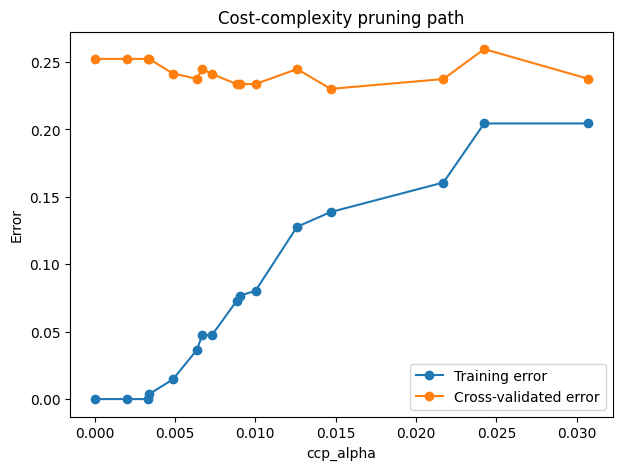

In [41]:
plt.figure(figsize=(7, 5))
plt.plot(cp_table["ccp_alpha"], cp_table["train_error"], marker="o", label="Training error")
plt.plot(cp_table["ccp_alpha"], cp_table["cv_error"], marker="o", label="Cross-validated error")
plt.xlabel("ccp_alpha")
plt.ylabel("Error")
plt.title("Cost-complexity pruning path")
plt.legend()
plt.show()


The table contains, among others:

- `ccp_alpha`: cost-complexity pruning parameter;
- `n_leaves`: number of terminal nodes;
- `depth`: depth of the tree;
- `train_error`: training error;
- `cv_error`: cross-validated error.

## Questions

<!--
1. What happens to the training error as the number of splits increases? Is this surprising?
-->

1. What happens to the cross-validated error as the tree becomes more complex? Does it always decrease?

1. Why is cross-validated error more relevant than training error for choosing the size of the tree?

> Write your answers here or, if available, in the online form provided for the exercise.


## 4.2 Select a pruned tree

We first select the tree with minimum cross-validated error.


In [42]:
best_row = cp_table["cv_error"].idxmin()
best_alpha = cp_table.loc[best_row, "ccp_alpha"]
best_alpha


np.float64(0.01468543621828293)

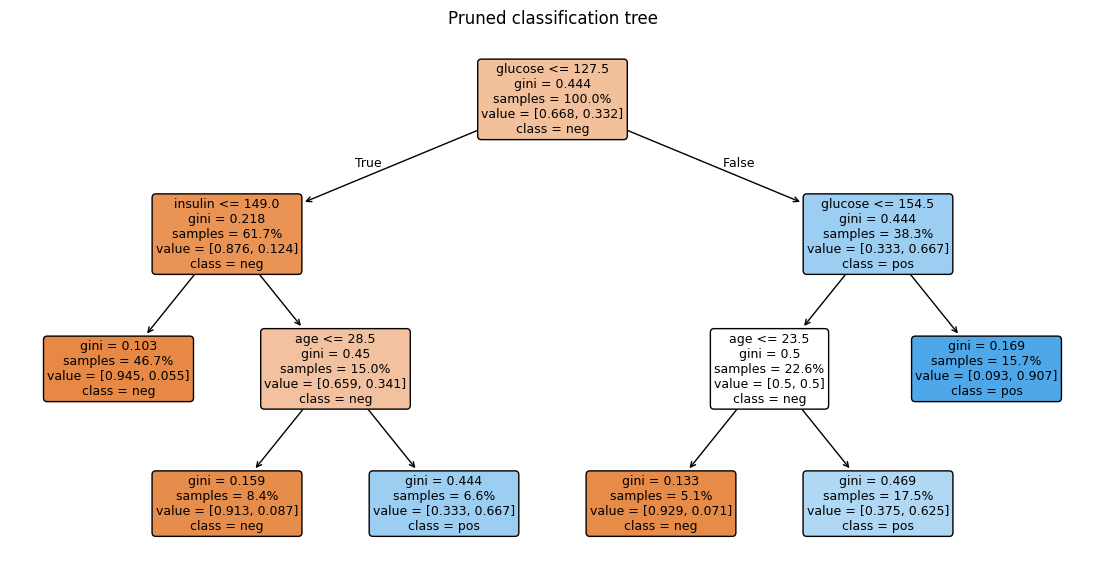

In [43]:
pruned_class = DecisionTreeClassifier(
    criterion="gini",
    random_state=random_state,
    ccp_alpha=best_alpha
)
pruned_class.fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(
    pruned_class,
    feature_names=X_train.columns,
    class_names=pruned_class.classes_,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=9
)
plt.title("Pruned classification tree")
plt.show()


## 4.3 Compare original and pruned trees


In [44]:
pred_test_pruned = pruned_class.predict(X_test)

conf_test_pruned = pd.DataFrame(
    confusion_matrix(y_test, pred_test_pruned, labels=labels),
    index=[f"Observed {x}" for x in labels],
    columns=[f"Predicted {x}" for x in labels]
)

conf_test_pruned


,Predicted neg,Predicted pos
Observed neg,57,22
Observed pos,10,29


In [45]:
metrics_unpruned = classification_metrics(y_test, pred_test_class, positive="pos")
metrics_pruned = classification_metrics(y_test, pred_test_pruned, positive="pos")

comparison_class = pd.concat(
    [metrics_unpruned, metrics_pruned],
    keys=["unpruned", "pruned"]
)

comparison_class.round(3)


,,accuracy,sensitivity,specificity,test_error
unpruned,0,0.695,0.487,0.797,0.305
pruned,0,0.729,0.744,0.722,0.271


## Questions

1. Has pruning reduced the size of the tree? Describe the main structural change.

<!--
1. Has pruning improved the test error in this particular split?

1. Suppose the pruned tree has a slightly worse test error but is much smaller. Could it still be preferable? Explain why.
-->

1. Explain pruning as a form of regularization. What is being penalized?

<!--
1. What is the connection between pruning and the bias-variance trade-off?
-->

> Write your answers here or, if available, in the online form provided for the exercise.


# Part 5. Regression trees using a quantitative response

We now illustrate the same ideas for a regression tree. Instead of predicting the binary response, we use `glucose` as a quantitative response.

This section is shorter because the aim is not to repeat the whole analysis, but to highlight what changes when the response is numerical.

## 5.1 Define a regression dataset

We remove the original categorical response `diabetes` from the predictors and use `glucose` as the response.


In [ ]:
reg_data = mydataset_cc.drop(columns="diabetes").copy()

X_reg = reg_data.drop(columns="glucose")
y_reg = reg_data["glucose"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    train_size=prop_train,
    random_state=random_state
)

train_reg = X_train_reg.copy()
train_reg["glucose"] = y_train_reg

test_reg = X_test_reg.copy()
test_reg["glucose"] = y_test_reg


## Questions

<!--
1. Why should `diabetes` be removed from the predictors if we use `glucose` as the response in this illustrative regression exercise? What would happen if we kept it?
-->

> Write your answer here.


## 5.2 Fit a regression tree


In [ ]:
tree_reg = DecisionTreeRegressor(
    random_state=random_state,
    ccp_alpha=0.0
)

tree_reg.fit(X_train_reg, y_train_reg)

print(export_text(tree_reg, feature_names=list(X_train_reg.columns), max_depth=4))


In [ ]:
plt.figure(figsize=(18, 9))
plot_tree(
    tree_reg,
    feature_names=X_train_reg.columns,
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=3,
    fontsize=9
)
plt.title("Initial regression tree, truncated to depth 3")
plt.show()


## Questions

1. What is predicted in each terminal node of a regression tree: a class, a probability, or a numerical value?

<!--
1. Choose one terminal node. What numerical prediction is assigned to observations falling into that node?
-->

1. Compare the interpretation of a terminal node in a classification tree and in a regression tree.

> Write your answers here or, if available, in the online form provided for the exercise.


## 5.3 Prediction error for a regression tree

For regression problems, the usual error measures are based on the difference between observed and predicted numerical values.


In [ ]:
pred_train_reg = tree_reg.predict(X_train_reg)
pred_test_reg = tree_reg.predict(X_test_reg)

mse_train = mean_squared_error(y_train_reg, pred_train_reg)
mse_test = mean_squared_error(y_test_reg, pred_test_reg)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print("Training MSE:", mse_train)
print("Test MSE:", mse_test)
print("Training RMSE:", rmse_train)
print("Test RMSE:", rmse_test)


In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(pred_test_reg, y_test_reg)
plt.xlabel("Predicted glucose")
plt.ylabel("Observed glucose")
plt.title("Regression tree: observed vs predicted values")

lims = [min(pred_test_reg.min(), y_test_reg.min()), max(pred_test_reg.max(), y_test_reg.max())]
plt.plot(lims, lims, linestyle="--")
plt.show()


## Questions

1. Why do we use MSE or RMSE instead of accuracy for a regression tree?

<!--
1. Compare training RMSE and test RMSE. What would a large difference suggest?

1. In the observed-versus-predicted plot, what would perfect predictions look like?
-->

> Write your answers here or, if available, in the online form provided for the exercise.


## 5.4 Pruning the regression tree


In [ ]:
path_reg = tree_reg.cost_complexity_pruning_path(X_train_reg, y_train_reg)
ccp_alphas_reg = path_reg.ccp_alphas[:-1]

cv_reg = KFold(n_splits=10, shuffle=True, random_state=random_state)

rows = []
for alpha in ccp_alphas_reg:
    reg = DecisionTreeRegressor(random_state=random_state, ccp_alpha=alpha)
    reg.fit(X_train_reg, y_train_reg)
    train_rmse = np.sqrt(mean_squared_error(y_train_reg, reg.predict(X_train_reg)))
    cv_rmse = -cross_val_score(
        reg,
        X_train_reg,
        y_train_reg,
        cv=cv_reg,
        scoring="neg_root_mean_squared_error"
    ).mean()
    rows.append({
        "ccp_alpha": alpha,
        "n_leaves": reg.get_n_leaves(),
        "depth": reg.get_depth(),
        "train_RMSE": train_rmse,
        "cv_RMSE": cv_rmse
    })

cp_table_reg = pd.DataFrame(rows)
cp_table_reg.head(15)


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(cp_table_reg["ccp_alpha"], cp_table_reg["train_RMSE"], marker="o", label="Training RMSE")
plt.plot(cp_table_reg["ccp_alpha"], cp_table_reg["cv_RMSE"], marker="o", label="Cross-validated RMSE")
plt.xlabel("ccp_alpha")
plt.ylabel("RMSE")
plt.title("Regression tree pruning path")
plt.legend()
plt.show()


In [ ]:
best_row_reg = cp_table_reg["cv_RMSE"].idxmin()
best_alpha_reg = cp_table_reg.loc[best_row_reg, "ccp_alpha"]

pruned_reg = DecisionTreeRegressor(
    random_state=random_state,
    ccp_alpha=best_alpha_reg
)
pruned_reg.fit(X_train_reg, y_train_reg)

plt.figure(figsize=(12, 6))
plot_tree(
    pruned_reg,
    feature_names=X_train_reg.columns,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=9
)
plt.title("Pruned regression tree")
plt.show()


In [ ]:
pred_test_reg_pruned = pruned_reg.predict(X_test_reg)
rmse_test_pruned = np.sqrt(mean_squared_error(y_test_reg, pred_test_reg_pruned))

comparison_reg = pd.DataFrame({
    "model": ["unpruned", "pruned"],
    "test_RMSE": [rmse_test, rmse_test_pruned],
    "terminal_nodes": [tree_reg.get_n_leaves(), pruned_reg.get_n_leaves()]
})

comparison_reg.round(3)


## Questions

<!--
1. Did pruning reduce the number of terminal nodes in the regression tree?

1. Did pruning improve the test RMSE in this particular split?

1. Why can a simpler tree be preferable even if its test RMSE is very similar to that of a larger tree?
-->

> Write your answers here or, if available, in the online form provided for the exercise.


# Part 6. Final synthesis

Answer the following questions without running more code.

## Questions

<!--
1. In what sense is a decision tree an interpretable model?

1. What are the main limitations of a single decision tree?

1. What aspects of the analysis would change if the dataset had many more predictors than observations?

1. Explain the difference between stopping a tree early and pruning a tree after growing it.
-->

1. Summarize, in 5-6 lines, the full workflow followed in this lab: data preparation, train/test split, model fitting, prediction error estimation, pruning and final interpretation.

> Write your answers here.


# Optional extension for another dataset

If another dataset is used instead of Pima, the core workflow remains the same:

1. define the response variable;
2. identify whether the task is classification or regression;
3. split the data into training and test sets;
4. fit an initial tree;
5. interpret the main splits and terminal nodes;
6. estimate test error using an appropriate metric;
7. use cross-validation to choose the degree of pruning;
8. compare the original and pruned trees;
9. justify the final model in terms of prediction and interpretability.
